## Titanic Dataset

**Jeremy Coleman**

This project uses the Titanic dataset to practice cleaning and exploring data. I'll be cleaning up missing values, doing some basic analysis, and making a few visualizations to see what patterns show up.

## Setup

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Ingestion

In [17]:
data = pd.read_csv("titanic.csv")
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Null Check

In [18]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Data Cleaning

First I'm going to fill in the missing age values using the median age. Then I'll drop the deck column since most of it is empty, and drop the two rows where embarked is missing.

In [19]:
def fix_age_column(frame):
    """
    Fills in missing age values using the median age.
    """
    typical_age = frame["age"].median()
    frame["age"] = frame["age"].fillna(typical_age)
    return frame

data = fix_age_column(data)
data["age"].isnull().sum()

np.int64(0)

In [20]:
def clean_bad_columns(frame):
    """Drops the deck column and removes rows with missing embarked values."""
    frame = frame.drop(columns=["deck"])
    frame = frame.dropna(subset=["embarked"])
    return frame

data = clean_bad_columns(data)
data.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Exploratory Analysis

I want to see if gender and passenger class had any effect on survival. There was always that idea of women and children first, and I want to see if they gave wealthy passengers priority as well.

In [21]:
def survival_by_gender(frame):
    """Survival rate grouped by gender."""
    breakdown = frame.groupby("sex")["survived"].mean()
    print(breakdown)

def survival_by_class(frame):
    """Survival rate grouped by passenger class."""
    breakdown = frame.groupby("pclass")["survived"].mean()
    print(breakdown)

survival_by_gender(data)
print("---")
survival_by_class(data)

sex
female    0.740385
male      0.188908
Name: survived, dtype: float64
---
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64


## Visualizations

Three charts looking at survival patterns across gender, passenger class, and age.

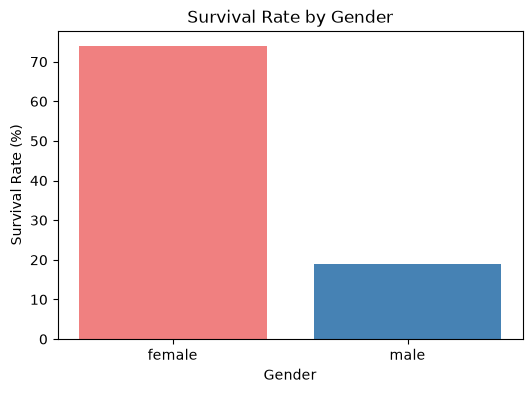

In [22]:
gender_survival = data.groupby("sex")["survived"].mean() * 100

plt.figure(figsize=(6, 4))
plt.bar(gender_survival.index, gender_survival.values, color=["lightcoral", "steelblue"])
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.show()

The above chart shows that female passengers survived at a much higher rate than males, around 74% compared to 19%. This lines up with the classic "Women and children first" line. 

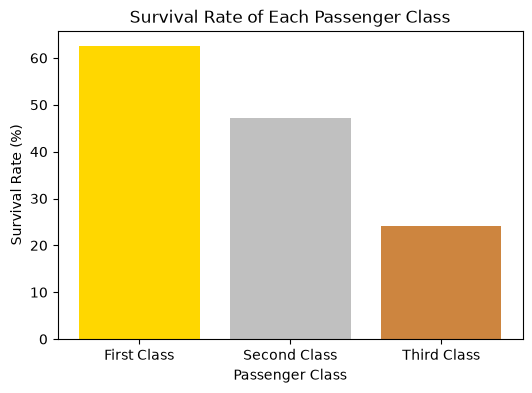

In [23]:
class_survival = data.groupby("pclass")["survived"].mean() * 100

plt.figure(figsize=(6, 4))
plt.bar(["First Class", "Second Class", "Third Class"], class_survival.values, color=["gold", "silver", "peru"])
plt.title("Survival Rate of Each Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.show()

The above chart shows first class passengers survived at about 63%, second class survived at around 47%, and third class was only around 24%. The richer you were the better your odds of survival, whether that was from having better access to the deck or just being given priority.

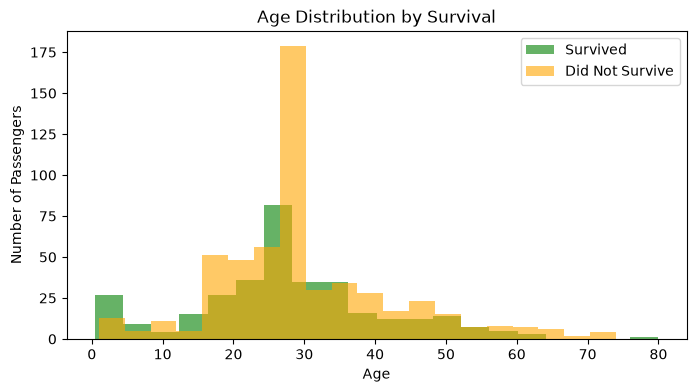

In [24]:
survived_passengers = data[data["survived"] == 1]["age"]
died_passengers = data[data["survived"] == 0]["age"]

plt.figure(figsize=(8, 4))
plt.hist(survived_passengers, bins=20, alpha=0.6, color="green", label="Survived")
plt.hist(died_passengers, bins=20, alpha=0.6, color="orange", label="Did Not Survive")
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

The above chart shows that the 15-30 age range took by far the most casualties which makes sense since they were the largest group on the ship. Young children show a slightly better survival rate, which supports the children first idea.

Below I just wanted to see who the 80 year old was that managed to survive.

In [25]:
data[data["age"] >= 75]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
630,1,1,male,80.0,0,0,30.0,S,First,man,True,Southampton,yes,True


## Summary

**What you learned from the dataset**

From the gender chart we can see that the "women" part of women and children first was definitely true in this case. The late 20's demographic definitely took the most casualties, by a long shot.

**Interesting patterns or insights**

It's pretty much what I expected from reading the stories about it. I can definitely see the crew prioritizing women and children, then the first class passengers, then second, then third. Another possibility is that 3rd class was just deeper in the bowels of the ship and it was harder for them to get out to the life boats. It is interesting that the ages you would think would be the hardiest took the most losses. 15-30 year olds were definitely the most represented in passengers but not nearly as much as they're represented in casualties.

**Limitations or assumptions**

The main limitation was that we had 177 missing ages that had to be filled in with the median. For assumptions, we can assume from the 3 classes survival rate that the richer you were, the more likely you were to get a seat in a lifeboat. You can see the one spike on the histogram that had more survivors than casualties and here I would assume that's because it was the women with children. That fits for the age where you would see them most represented.

**Anything surprising or unclear**

The surprising part was the one 80 year old man who survived. It surprised me so much that I had to look him up and see exactly who he was. Turns out he was 80 WHEN HE DIED 32 YEARS AFTER THE SHIP SANK, not while he was a passenger. His name was Algernon Henry Wilson Barkworth, and he was actually 47-48 when it sank. This is a known error in this dataset. I assumed this was a dataset made from passenger manifests but that doesn't seem to be entirely true, at least in this case.

